Bhuwan Basnet
2408849 | L6CG9

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install nltk wordcloud --quiet

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!
TensorFlow version: 2.20.0


In [3]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/AI/Hotel_Dataset/Hotel_Reviews.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20491, 2)

First 5 rows:


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [7]:
print(df.columns.tolist())
print(df.head())

['Review', 'Rating']
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5


Sentiment Distribution:
Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64


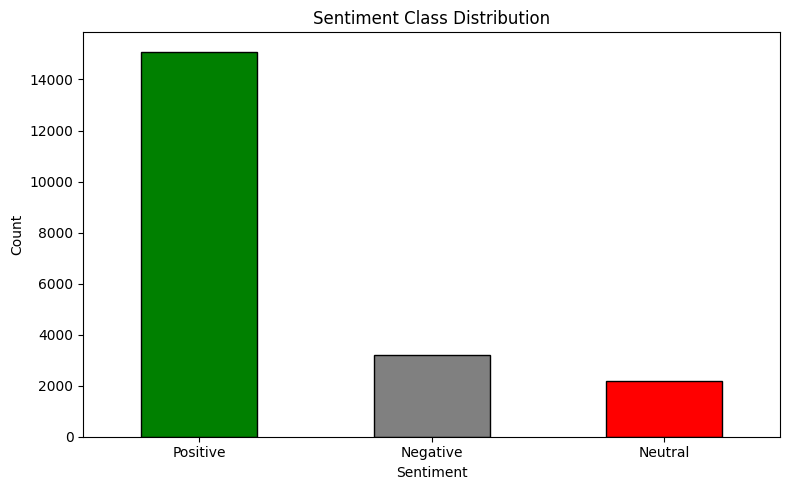

In [8]:
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Rating'].apply(map_sentiment)

print("Sentiment Distribution:")
print(df['Sentiment'].value_counts())

plt.figure(figsize=(8, 5))
df['Sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'], edgecolor='black')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("Sample cleaned reviews:")
for i in range(3):
    print(f"\nOriginal: {df['Review'].iloc[i]}")
    print(f"Cleaned:  {df['Cleaned_Review'].iloc[i]}")

Sample cleaned reviews:

Original: nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
Cleaned:  nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillow soundproof like heard music room night morning loud bang door opening closing hear people talking hallway ma

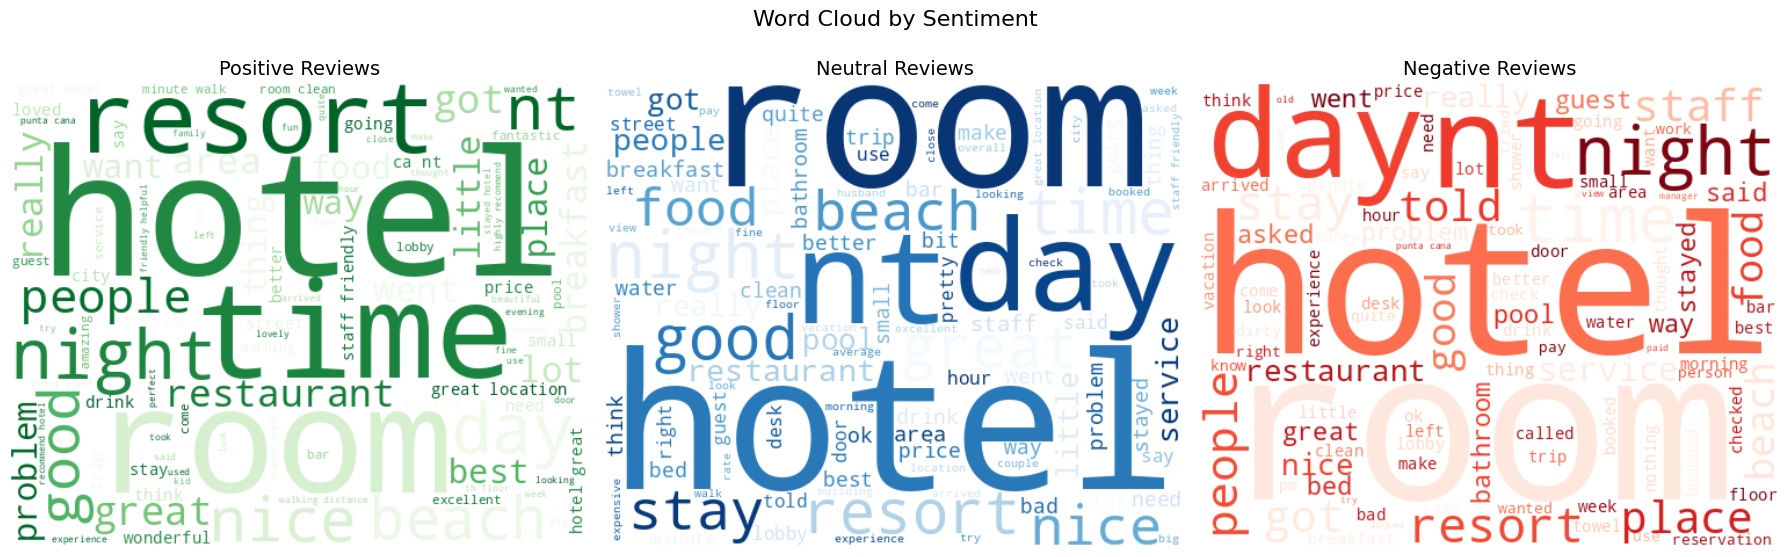

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = ['Positive', 'Neutral', 'Negative']
colors = ['Greens', 'Blues', 'Reds']

for ax, sentiment, color in zip(axes, sentiments, colors):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Review'])
    wordcloud = WordCloud(width=500, height=400, background_color='white',
                          colormap=color, max_words=100).generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'{sentiment} Reviews', fontsize=14)
    ax.axis('off')

plt.suptitle('Word Cloud by Sentiment', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# Encode labels
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['Label'] = df['Sentiment'].map(label_map)

X = df['Cleaned_Review'].values
y = df['Label'].values

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 16392
Testing samples:  4099


In [12]:
# Tokenize
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length
lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"Max sequence length (95th percentile): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

print(f"X_train shape: {X_train_pad.shape}")
print(f"X_test shape:  {X_test_pad.shape}")

Max sequence length (95th percentile): 255
X_train shape: (16392, 255)
X_test shape:  (4099, 255)


In [13]:
EMBED_DIM = 64

model1_rnn = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.SimpleRNN(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
], name='Simple_RNN')

model1_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1_rnn.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

import time
start = time.time()

history1 = model1_rnn.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

rnn_time = time.time() - start
print(f"\nSimple RNN Training Time: {rnn_time:.2f} seconds")

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 62s 116ms/step - accuracy: 0.7312 - loss: 0.7653 - val_accuracy: 0.7365 - val_loss: 0.7547
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 60s 117ms/step - accuracy: 0.7411 - loss: 0.7459 - val_accuracy: 0.7292 - val_loss: 0.7641
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 74s 103ms/step - accuracy: 0.7400 - loss: 0.7471 - val_accuracy: 0.7365 - val_loss: 0.7402
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 72s 83ms/step - accuracy: 0.7357 - loss: 0.7422 - val_accuracy: 0.7365 - val_loss: 0.7448
Epoch 5/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.7383 - loss: 0.7369 - val_accuracy: 0.7353 - val_loss: 0.7420
Epoch 6/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy: 0.7439 - loss: 0.7329 - val_accuracy: 0.7343 - val_loss: 0.7427
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Simple RNN Training Time: 430.93 seconds


In [16]:
model2_lstm = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
], name='LSTM_Model')

model2_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2_lstm.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

start = time.time()

history2 = model2_lstm.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop2],
    verbose=1
)

lstm_time = time.time() - start
print(f"\nLSTM Training Time: {lstm_time:.2f} seconds")

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 147s 278ms/step - accuracy: 0.7351 - loss: 0.7782 - val_accuracy: 0.7365 - val_loss: 0.7546
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 139s 270ms/step - accuracy: 0.7405 - loss: 0.7602 - val_accuracy: 0.7333 - val_loss: 0.7597
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 269ms/step - accuracy: 0.7448 - loss: 0.7469 - val_accuracy: 0.7341 - val_loss: 0.7603
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 141s 268ms/step - accuracy: 0.7458 - loss: 0.7374 - val_accuracy: 0.7365 - val_loss: 0.7548
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

LSTM Training Time: 572.58 seconds


In [18]:
!pip install numpy==1.23.5 --quiet
!pip install gensim --quiet

import gensim.downloader as api
print("Downloading GloVe embeddings... this may take a few minutes")
embedding_model = api.load('glove-wiki-gigaword-50')
print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 100.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.3 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Done!


In [19]:
embedding_dim = 50
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (10000, 50)


In [20]:
model3_w2v = models.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
], name='LSTM_Word2Vec')

model3_w2v.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3_w2v.summary()

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
early_stop3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

start = time.time()

history3 = model3_w2v.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop3],
    verbose=1
)

w2v_time = time.time() - start
print(f"\nLSTM + Word2Vec Training Time: {w2v_time:.2f} seconds")

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 144s 272ms/step - accuracy: 0.7343 - loss: 0.7793 - val_accuracy: 0.7365 - val_loss: 0.7551
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7306 - loss: 0.7731

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_history = [history1, history2, history3]
model_names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
colors = ['steelblue', 'orange', 'green']

for i, (hist, name, color) in enumerate(zip(models_history, model_names, colors)):
    # Accuracy
    axes[0][i].plot(hist.history['accuracy'], label='Train', color=color)
    axes[0][i].plot(hist.history['val_accuracy'], label='Val', color=color, linestyle='--')
    axes[0][i].set_title(f'{name} - Accuracy')
    axes[0][i].set_xlabel('Epoch')
    axes[0][i].set_ylabel('Accuracy')
    axes[0][i].legend()
    axes[0][i].grid(True)

    # Loss
    axes[1][i].plot(hist.history['loss'], label='Train', color=color)
    axes[1][i].plot(hist.history['val_loss'], label='Val', color=color, linestyle='--')
    axes[1][i].set_title(f'{name} - Loss')
    axes[1][i].set_xlabel('Epoch')
    axes[1][i].set_ylabel('Loss')
    axes[1][i].legend()
    axes[1][i].grid(True)

plt.suptitle('Model Comparison: RNN vs LSTM vs LSTM+Word2Vec', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
label_names = ['Negative', 'Neutral', 'Positive']

for model, name in zip([model1_rnn, model2_lstm, model3_w2v], model_names):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    loss, acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)
    print(f"Validation Accuracy: {acc*100:.2f}%")
    print(f"Validation Loss:     {loss:.4f}")

    y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Show misclassified examples
best_model = model3_w2v  # use best performing model
y_pred_all = np.argmax(best_model.predict(X_test_pad, verbose=0), axis=1)
y_true_all = np.argmax(y_test_cat, axis=1)

misclassified_idx = np.where(y_pred_all != y_true_all)[0]

print("Sample Misclassified Reviews:\n")
for idx in misclassified_idx[:3]:
    print(f"Review:     {X_test[idx]}")
    print(f"True Label: {label_names[y_true_all[idx]]}")
    print(f"Predicted:  {label_names[y_pred_all[idx]]}")
    print("-" * 60)

In [ ]:
print("=" * 60)
print(f"{'Model':<25} {'Val Accuracy':>15} {'Train Time':>15}")
print("=" * 60)

for model, name, t in zip(
    [model1_rnn, model2_lstm, model3_w2v],
    model_names,
    [rnn_time, lstm_time, w2v_time]
):
    acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)[1]
    print(f"{name:<25} {acc*100:>14.2f}% {t:>13.2f}s")

print("=" * 60)